In [1]:
# This is where I will Analyze Rain/Snow

In [2]:
import pandas as pd
daily_ridership = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Daily_Manhattan_Totals.csv")
daily_ridership

,date,ridership
0,2023-01-01,1013185
1,2023-01-02,1062726
2,2023-01-03,1734883
3,2023-01-04,1862526
4,2023-01-05,1865376
...,...,...
360,2023-12-27,1668616
361,2023-12-28,1769432
362,2023-12-29,1846550
363,2023-12-30,1469037


In [3]:
daily_weather = pd.read_csv("../../data/01-interim/Weather/CLEANED_CentralPark_Weather2023.csv")
daily_weather

,Station,Name,Latitude,Longitude,Date,Precipitation,Snow,Avg_Temp,Max_Temp,Min_Temp,Rain?,Snow?
0,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-01,0.00,0.0,52.0,55.0,49.0,no,no
1,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-02,0.02,0.0,52.5,56.0,49.0,yes,no
2,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-03,0.42,0.0,52.5,58.0,47.0,yes,no
3,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-04,0.02,0.0,57.5,66.0,49.0,yes,no
4,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-05,0.01,0.0,47.0,50.0,44.0,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...
360,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-12-27,0.32,0.0,47.5,50.0,45.0,yes,no
361,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-12-28,1.22,0.0,52.0,55.0,49.0,yes,no
362,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-12-29,0.05,0.0,50.5,55.0,46.0,yes,no
363,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-12-30,0.00,0.0,42.5,46.0,39.0,no,no


In [4]:
daily_weather = daily_weather.drop(['Station','Name','Latitude','Longitude','Avg_Temp','Max_Temp','Min_Temp'], axis = 1)
daily_weather

,Date,Precipitation,Snow,Rain?,Snow?
0,2023-01-01,0.00,0.0,no,no
1,2023-01-02,0.02,0.0,yes,no
2,2023-01-03,0.42,0.0,yes,no
3,2023-01-04,0.02,0.0,yes,no
4,2023-01-05,0.01,0.0,yes,no
...,...,...,...,...,...
360,2023-12-27,0.32,0.0,yes,no
361,2023-12-28,1.22,0.0,yes,no
362,2023-12-29,0.05,0.0,yes,no
363,2023-12-30,0.00,0.0,no,no


In [5]:
daily_ridership['date'] = pd.to_datetime(daily_ridership['date'])
daily_weather['Date'] = pd.to_datetime(daily_weather['Date'])

Correlation Matrix:
               Ridership  Precipitation      Snow
Ridership       1.000000      -0.181575  0.020805
Precipitation  -0.181575       1.000000  0.011625
Snow            0.020805       0.011625  1.000000


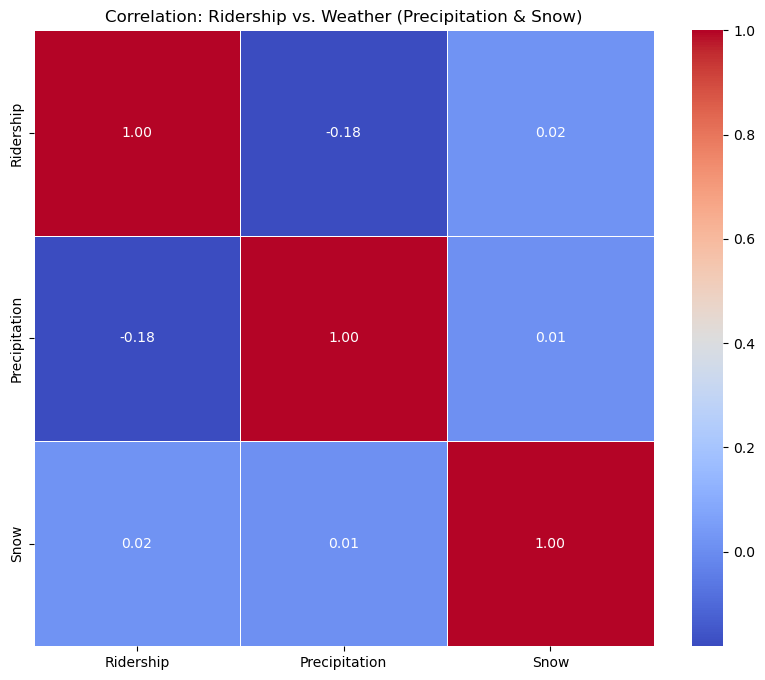

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Normalize the column names for merging
# Your first dataframe has 'date' and the second has 'Date'
daily_ridership.rename(columns={'date': 'Date', 'ridership': 'Ridership'}, inplace=True)

# 2. Merge the dataframes on the Date column
# We use an 'inner' join to only correlate dates that exist in both datasets
daily_merged = pd.merge(daily_ridership, daily_weather, on='Date')

# 3. Ensure the columns are in the correct format (as specified)
daily_merged['Ridership'] = daily_merged['Ridership'].astype(int)
daily_merged['Precipitation'] = daily_merged['Precipitation'].astype(float)
daily_merged['Snow'] = daily_merged['Snow'].astype(float)

# 4. Calculate the correlation matrix
# This uses the Pearson correlation coefficient by default
correlation_matrix = daily_merged[['Ridership', 'Precipitation', 'Snow']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# 5. Visualize the correlations with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Ridership vs. Weather (Precipitation & Snow)')
plt.savefig('ridership_weather_correlation.png')

Updated Correlation Matrix:
               Ridership  Precipitation      Snow  Rain_binary  Snow_binary
Ridership       1.000000      -0.181575  0.020805    -0.146880     0.041938
Precipitation  -0.181575       1.000000  0.011625     0.498035    -0.001136
Snow            0.020805       0.011625  1.000000     0.126729     0.858309
Rain_binary    -0.146880       0.498035  0.126729     1.000000     0.147649
Snow_binary     0.041938      -0.001136  0.858309     0.147649     1.000000


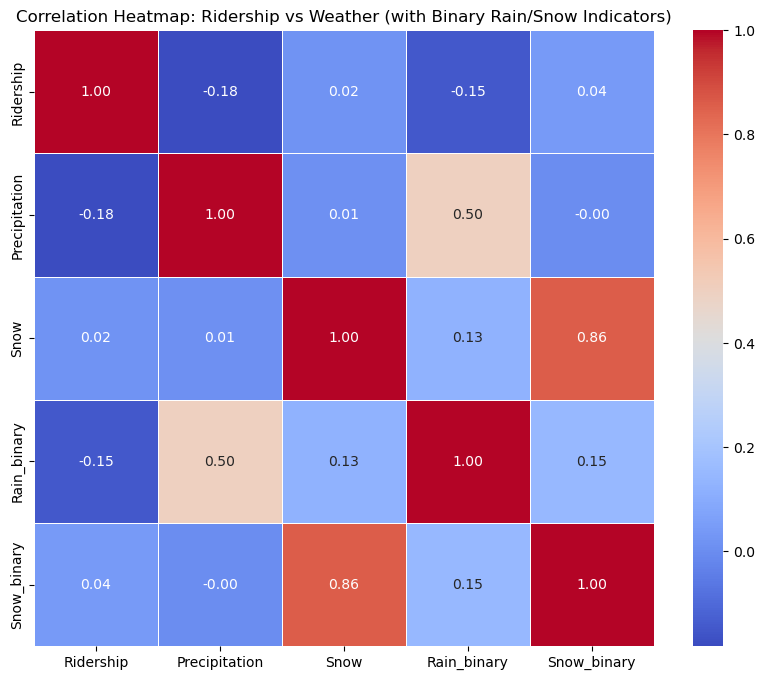

In [8]:
# 3. Convert 'yes'/'no' strings to 1/0 integers
# Assuming 'Rain' and 'Snow_string' are the names of the new string columns
# We'll create new columns for clarity, but you can overwrite if you prefer
daily_merged['Rain_binary'] = daily_merged['Rain?'].map({'yes': 1, 'no': 0})
daily_merged['Snow_binary'] = daily_merged['Snow?'].map({'yes': 1, 'no': 0})

# 4. Calculate correlation matrix including the new binary columns
# Note: Ensure you include all relevant column names in the list below
cols_to_correlate = [
    'Ridership', 
    'Precipitation', 
    'Snow',        # This is the original float/amount column
    'Rain_binary', # The new binary indicator
    'Snow_binary'  # The new binary indicator
]

correlation_matrix = daily_merged[cols_to_correlate].corr()

print("Updated Correlation Matrix:")
print(correlation_matrix)

# 5. Visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Ridership vs Weather (with Binary Rain/Snow Indicators)')
plt.savefig('correlation_with_binary_indicators.png')

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare the features (X) and target (y)
# We include both the continuous amounts and the binary 'yes/no' indicators
X = daily_merged[['Precipitation', 'Snow']]
y = daily_merged['Ridership']

# 2. Scale the features
# This allows us to compare coefficients directly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

In [13]:
# Create a summary of the coefficients
coefficients = pd.DataFrame({
    'Feature': ['Precipitation', 'Snow'],
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Standardized Coefficients:")
print(coefficients)

# Evaluate the model
print(f"\nR-squared Score: {r2_score(y_test, y_pred):.4f}")

Standardized Coefficients:
         Feature   Coefficient
1           Snow  17337.135000
0  Precipitation -67116.300504

R-squared Score: 0.0442


In [ ]:
# From this it appears the weather at Central Park has 
# very little impact on the overall ridership in Manhattan.
# The precipitation column does appear to have a more significant
# impact than snow, and they have inverse impacts on ridership.